# Data Loaders and Mini‑Batch Processing in PyTorch

**Author:** Phabel Antonio López Delgado, BSc.

This notebook demonstrates how to use PyTorch's `Dataset` and `DataLoader` classes to efficiently load and manage data in mini‑batches. Mini‑batch processing is essential for training neural networks, as it balances computational efficiency and convergence quality.

**Key Concepts Covered:**
- Creating a custom `Dataset` class for structured data (CSV files).
- Accessing individual samples and their labels.
- Using `DataLoader` to create mini‑batches with shuffling.
- Training a neural network with mini‑batch gradient descent.
- Comparing training time with different batch sizes.

**Key Techniques & Libraries:**
- `pandas` – loading CSV data.
- `torch.utils.data.Dataset` – base class for custom datasets.
- `torch.utils.data.DataLoader` – batching and shuffling.
- `torch.nn` – building a simple neural network.

**Objective:**
To understand how to efficiently load and batch data for neural network training, and to appreciate the trade‑offs in choosing batch size.

## Why Mini‑Batches?

In neural network training, we typically use **mini‑batch gradient descent**, where the model parameters are updated after processing a small batch of samples (e.g., 32, 64, 128), rather than a single sample (stochastic gradient descent) or the entire dataset (batch gradient descent).

Benefits of mini‑batches:
- **Efficiency**: Hardware acceleration (GPUs) is optimised for batch operations.
- **Convergence**: Mini‑batches provide a good trade‑off between the noise of SGD and the stability of full batch.
- **Memory**: Fits within GPU memory limits.

In [1]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Set random seed for reproducibility
torch.manual_seed(42)

print("All imports successful.")

All imports successful.


## 1. Custom Dataset Class

We define a custom `Dataset` class that loads data from a CSV file. The class:

- Loads the CSV file using `pandas`.
- Separates features (`X`) and labels (`y`).
- Converts them to PyTorch tensors.
- Implements `__len__()` and `__getitem__()` methods.

### Dataset Structure

The CSV file should have:
- The last column as the target label (`Y`).
- All other columns as features.
- The first column may be an index (ignored by setting `index_col=0`).

In [16]:
class CSVDataset(Dataset):
    def __init__(self, file_name, target_column='Y'):
        # Read CSV without index column
        dataframe = pd.read_csv(file_name)

        # Separate features and target
        X = dataframe.drop(columns=[target_column]).values
        y = dataframe[target_column].values

        # Convert to tensors
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.n_samples = len(self.y)

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

## 2. Loading the Dataset

We instantiate the `CSVDataset` with the path to the CSV file.

In [17]:
import kagglehub
import pandas as pd

# Download the dataset from Kaggle
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
csv_path = f"{path}/data.csv"

# Load and clean
data = pd.read_csv(csv_path, index_col=0)
data = data.drop('Unnamed: 32', axis=1, errors='ignore')
data['Y'] = (data['diagnosis'] == 'M').astype(int)
data = data.drop('diagnosis', axis=1)

# Save as dataset.csv in the current folder
data.to_csv('dataset.csv', index=False)
print("dataset.csv downloaded and saved!")

dataset.csv downloaded and saved!


## 3. Mini‑Batches with DataLoader

We use `DataLoader` to manage mini‑batches. The `DataLoader`:

- Divides the dataset into batches of size `batch_size`.
- Shuffles the data at the start of each epoch (if `shuffle=True`).
- Supports multi‑worker loading for speed.

We create a DataLoader with batch size 64.

In [18]:
# Load the dataset using the custom class
dataset = CSVDataset('dataset.csv')

# Create DataLoader with batch size 64
loader = DataLoader(dataset, batch_size=64, shuffle=True)

# Display a batch
for X_batch, y_batch in loader:
    print(f"Batch X shape: {X_batch.shape}")
    print(f"Batch y shape: {y_batch.shape}")
    print(f"Batch labels: {y_batch}")
    break

Batch X shape: torch.Size([64, 30])
Batch y shape: torch.Size([64])
Batch labels: tensor([0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
        0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
        0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1])


## 4. Training a Neural Network with Mini‑Batches
We train a simple neural network using mini‑batch gradient descent. The model has:

* Input layer: 30 features.
* Hidden layer: 60 neurons with Tanh activation.
* Output layer: 2 neurons (binary classification) with Softmax.

We use CrossEntropyLoss and the Adam optimizer.

Comparison of Batch Sizes
We demonstrate the effect of batch size on training time and efficiency.

In [25]:
%%time
# DataLoader with batch size 64
loader = DataLoader(dataset, batch_size=64, shuffle=True)

# Model (same architecture)
model = nn.Sequential(
    nn.Linear(dataset.X.shape[1], 60),
    nn.Tanh(),
    nn.Linear(60, 2),
    nn.Softmax(dim=1)
)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop with batch size 64 (100 epochs)
epochs = 100
for epoch in tqdm(range(epochs)):
    for X_batch, y_batch in loader:
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

print("Training complete with batch size 64 (100 epochs).")

100%|██████████| 100/100 [00:01<00:00, 81.50it/s]

Training complete with batch size 64 (100 epochs).
CPU times: total: 1.55 s
Wall time: 1.23 s


### Comparison: Batch Size 1 (Stochastic Gradient Descent)

When `batch_size = 1`, we perform **stochastic gradient descent** (SGD), updating parameters after each sample. This is the slowest approach but can sometimes escape local minima due to high noise.

In [24]:
%%time
# DataLoader with batch size 1 (SGD)
loader_sgd = DataLoader(dataset, batch_size=1, shuffle=True)

# Model (same architecture)
model_sgd = nn.Sequential(
    nn.Linear(dataset.X.shape[1], 60),
    nn.Tanh(),
    nn.Linear(60, 2),
    nn.Softmax(dim=1)
)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer_sgd = torch.optim.Adam(model_sgd.parameters(), lr=0.01)

# Training loop with batch size 1
epochs_sgd = 1000
for epoch in tqdm(range(epochs_sgd)):
    for X_batch, y_batch in loader_sgd:
        y_pred = model_sgd(X_batch)
        loss = criterion(y_pred, y_batch)

        optimizer_sgd.zero_grad()
        loss.backward()
        optimizer_sgd.step()

print("Training complete with batch size 1 (1000 epochs).")

100%|██████████| 1000/1000 [07:14<00:00,  2.30it/s]

Training complete with batch size 1.
CPU times: total: 7min 9s
Wall time: 7min 14s


## 5. Choosing the Right Batch Size

| Batch Size | Advantages | Disadvantages |
|------------|------------|---------------|
| 1 (SGD)    | High noise can escape local minima | Slow, unstable convergence |
| Full dataset (Batch GD) | Stable, accurate gradient | Slow, memory-intensive, prone to local minima |
| Mini‑batch (e.g., 32, 64, 128) | Fast, good convergence | Requires tuning |

In practice, batch sizes are often powers of 2 (32, 64, 128, 256) to align with GPU memory architecture.

## Comparison: Batch Size 64 vs Batch Size 1

| Batch Size | Epochs | Training Time | Convergence Speed |
|------------|--------|---------------|-------------------|
| 64         | 100    | ~2 seconds    | Fast, stable      |
| 1 (SGD)    | 1000   | ~7 minutes    | Slow, noisy       |

**Key Takeaway:** Mini‑batch training (batch size 64) is significantly faster and provides good convergence, while SGD (batch size 1) is much slower and noisier.

## Summary and Next Steps

**Accomplished:**
- Created a custom `Dataset` class for loading CSV data.
- Used `DataLoader` to create mini‑batches with shuffling.
- Trained a neural network with batch size 64.
- Compared training time with batch size 1 (SGD).

**Key Results:**
- Batch size 64 trained 100 epochs in approximately 2 seconds.
- Batch size 1 trained 1000 epochs in approximately 7 minutes.
- Mini‑batch training is significantly faster and provides good convergence.

**Key Insights:**
- `DataLoader` abstracts the complexity of batching and shuffling.
- Mini‑batches strike a balance between speed and convergence quality.
- The choice of batch size affects training speed, memory usage, and model performance.
- For most tasks, batch sizes of 32–128 are a good starting point.

**Suggested Next Steps:**
1. **Experiment with different batch sizes** – try 32, 128, 256 and compare training time and accuracy.
2. **Use a validation set** – split data into train/val and monitor performance.
3. **Add data augmentation** – apply random transforms to increase dataset diversity.
4. **Use multi‑worker DataLoader** – set `num_workers > 0` for faster data loading.

**Reflection:**
Efficient data loading is a critical part of any deep learning pipeline. The `Dataset` and `DataLoader` classes in PyTorch provide a flexible and powerful interface for handling data of various types and sizes. Understanding how to use them effectively allows practitioners to focus on model design rather than data management.

# Available Datasets for Machine Learning

**Author:** Phabel Antonio López Delgado, BSc.

This part provides an overview of commonly used datasets for machine learning and deep learning. We explore both structured datasets (tabular data) and unstructured datasets (images, text) available from various sources.

**Key Concepts Covered:**
- Structured datasets: Iris, Breast Cancer Wisconsin, and other scikit‑learn datasets.
- Unstructured datasets: Oxford‑IIIT Pet (images) from TorchVision.
- Loading datasets from Kaggle, UCI, scikit‑learn, and TorchVision.
- Visualising image datasets.

**Key Techniques & Libraries:**
- `sklearn.datasets` – structured datasets.
- `torchvision.datasets` – image datasets.
- `pandas` – data manipulation.
- `matplotlib` – visualisation.

**Objective:**
To become familiar with the variety of datasets available for machine learning tasks and how to load and explore them.

In [26]:
import pandas as pd
import torch
import torchvision
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_breast_cancer, load_digits
import kagglehub

print("All imports successful.")

All imports successful.


## 1. Structured Datasets

Structured datasets are organised in tabular format with rows (samples) and columns (features). They are widely available from repositories such as:

- [Kaggle](https://www.kaggle.com/datasets)
- [UCI Machine Learning Repository](https://archive.ics.uci.edu/)
- [scikit‑learn Toy Datasets](https://scikit-learn.org/stable/datasets/toy_dataset.html)

### 1.1 Iris Dataset

The Iris dataset is one of the most famous datasets in pattern recognition. It contains 150 samples of iris flowers, with 4 features (sepal length, sepal width, petal length, petal width) and 3 classes (Setosa, Versicolour, Virginica).

In [29]:
# Load Iris dataset from sklearn
iris_data = load_iris()
X = iris_data.data
y = iris_data.target

# Convert to pandas DataFrame
df_iris = pd.DataFrame(X, columns=iris_data.feature_names)
df_iris['target'] = y

print(f"Dataset shape: {df_iris.shape}")
print("\nFirst 5 rows:")
df_iris.head()

Dataset shape: (150, 5)

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [30]:
print(load_iris().DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [31]:
df_iris.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [32]:
# Load Iris dataset from sklearn
iris_data = load_iris()
X = iris_data.data
y = iris_data.target

# Convert to pandas DataFrame
df_iris = pd.DataFrame(X, columns=iris_data.feature_names)
df_iris['target'] = y

print(f"Dataset shape: {df_iris.shape}")
print("\nFirst 5 rows:")
df_iris.head()

Dataset shape: (150, 5)

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [33]:
print(load_iris().DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [34]:
df_iris.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### 1.2 Other scikit‑learn Datasets

scikit‑learn provides many other toy datasets:

- `load_digits()` – handwritten digits (8×8 images).
- `load_breast_cancer()` – breast cancer Wisconsin dataset.
- `load_wine()` – wine classification.

All follow the same API: `data` (features) and `target` (labels).

In [36]:
# Load breast cancer dataset
cancer_data = load_breast_cancer()
df_cancer = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df_cancer['target'] = cancer_data.target

print(f"Cancer dataset shape: {df_cancer.shape}")
print("\nFeature names:")
print(cancer_data.feature_names)
print("\nTarget names:", cancer_data.target_names)

Cancer dataset shape: (569, 31)

Feature names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target names: ['malignant' 'benign']


## 2. Unstructured Datasets

Unstructured datasets include images, text, and graphs. They require special handling and are often loaded from dedicated repositories.

### Image Datasets

Common image datasets:
- **MNIST** – handwritten digits.
- **CIFAR‑10** – 10 classes of objects.
- **Oxford‑IIIT Pet** – images of cats and dogs.
- **ImageNet** – large‑scale image classification.

In PyTorch, use `torchvision.datasets` to load image datasets.

In [37]:
# Download and load Oxford‑IIIT Pet dataset
# This will download images and annotations (can take several minutes)
data_pets = torchvision.datasets.OxfordIIITPet(
    root=".",
    download=True
)

print(f"Dataset size: {len(data_pets)}")
print(f"First sample type: {type(data_pets[0])}")
print(f"Image shape: {data_pets[0][0].size}")
print(f"Label: {data_pets[0][1]}")

100%|██████████| 792M/792M [01:43<00:00, 7.62MB/s]  
100%|██████████| 19.2M/19.2M [00:03<00:00, 4.85MB/s]


Dataset size: 3680
First sample type: <class 'tuple'>
Image shape: (394, 500)
Label: 0


In [38]:
def show_images(dataset, num_samples=6, cols=2, figsize=(20, 15)):
    """
    Display a grid of images from a dataset.

    Args:
        dataset (Dataset): PyTorch dataset with images.
        num_samples (int): Number of images to display.
        cols (int): Number of columns in the grid.
        figsize (tuple): Figure size.
    """
    rows = (num_samples + cols - 1) // cols
    plt.figure(figsize=figsize)
    for i in range(min(num_samples, len(dataset))):
        plt.subplot(rows, cols, i + 1)
        img, label = dataset[i]
        plt.imshow(img)
        plt.title(f"Label: {label}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

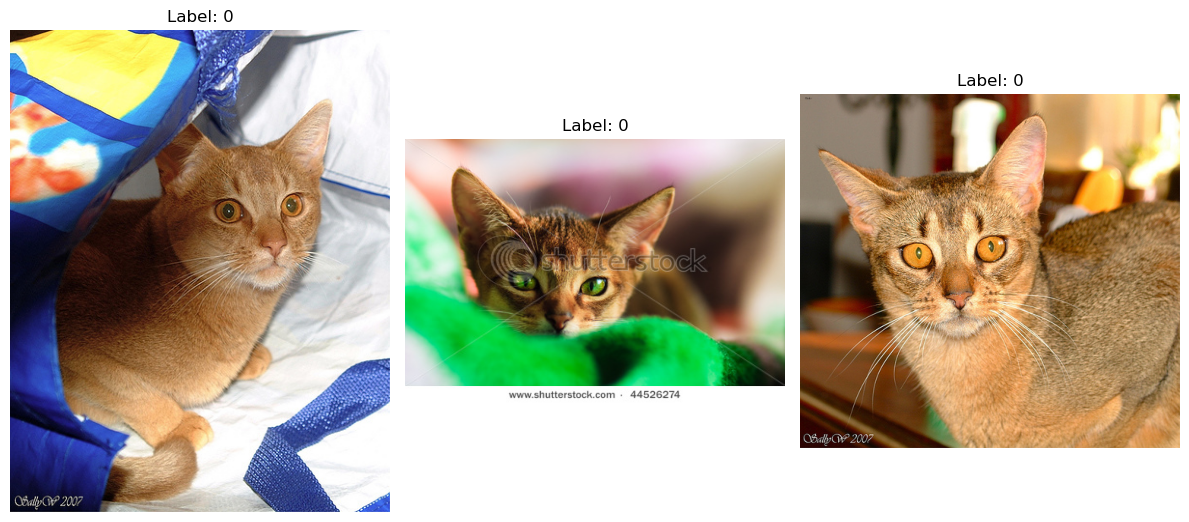

In [39]:
# Display 3 images from the Oxford Pet dataset
show_images(data_pets, num_samples=3, cols=3, figsize=(12, 8))

### Text Datasets

Text datasets are available from:
- [HuggingFace Datasets](https://huggingface.co/datasets) – large collection of NLP datasets.
- [IMDB Dataset](https://developer.imdb.com/non-commercial-datasets/) – movie reviews for sentiment analysis.
- [Stanford Sentiment Treebank](https://nlp.stanford.edu/sentiment/code.html) – fine-grained sentiment labels.

In PyTorch, use `torchtext.datasets` for text data (though it is less commonly used now in favour of HuggingFace's `datasets` library).

## 3. Summary of Dataset Repositories

| Repository | Type | Examples |
|------------|------|----------|
| [Kaggle](https://www.kaggle.com/datasets) | Structured, images, text | Titanic, House Prices, MNIST |
| [UCI](https://archive.ics.uci.edu/) | Structured | Iris, Wine, Breast Cancer |
| [scikit‑learn](https://scikit-learn.org/stable/datasets/) | Structured, toy datasets | Iris, Digits, Boston Housing |
| [TorchVision](https://pytorch.org/vision/stable/datasets.html) | Images | MNIST, CIFAR‑10, Oxford Pets |
| [HuggingFace](https://huggingface.co/datasets) | Text, images, audio | IMDB, SQuAD, GLUE |

## Summary and Next Steps

**Accomplished:**
- Loaded structured datasets from scikit‑learn (Iris, Breast Cancer).
- Converted them to pandas DataFrames for exploration.
- Loaded the Oxford‑IIIT Pet image dataset from TorchVision.
- Visualised sample images from the dataset.
- Reviewed common repositories for structured and unstructured datasets.

**Key Insights:**
- scikit‑learn provides convenient access to many structured toy datasets.
- TorchVision and TorchText provide access to unstructured image and text datasets.
- Understanding the available datasets helps in selecting appropriate benchmarks for machine learning tasks.
- The same `Dataset` and `DataLoader` classes can be used with these datasets for training.

**Suggested Next Steps:**
1. **Explore other datasets** – try CIFAR‑10, MNIST, or Fashion‑MNIST.
2. **Build a classifier** – train a model on one of these datasets.
3. **Use DataLoader with these datasets** – combine with the previous notebook on DataLoader.
4. **Extend to HuggingFace datasets** – load and explore text datasets.

**Reflection:**
Having access to a wide variety of datasets is essential for developing and benchmarking machine learning models. This notebook provides an introduction to some of the most commonly used datasets and the tools to load and explore them. Familiarity with these datasets is an important skill for any machine learning practitioner.